In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('/kaggle/input/datasets/satyamsatyarthi2006/titanic-survival/Titanic-Dataset.xls')
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

Null values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


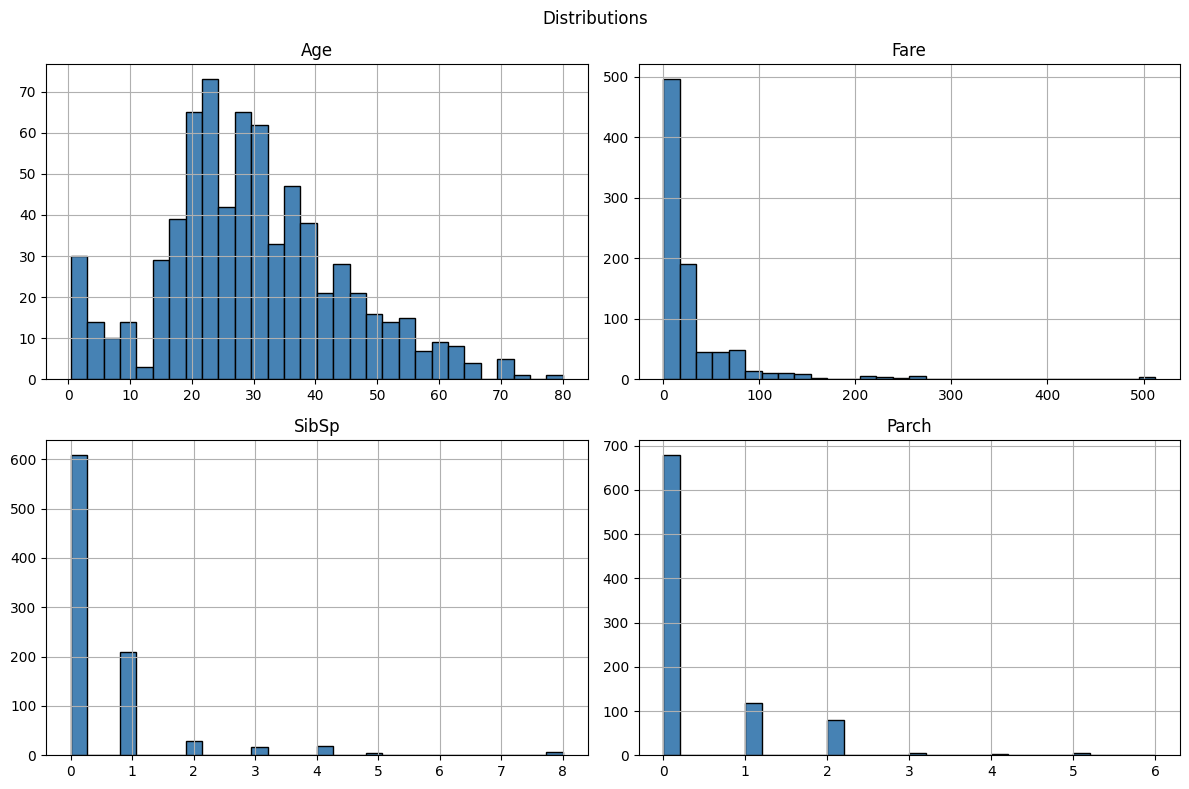

Nulls after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Shape: (891, 8)
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2
Shape: (891, 8)
   Survived  Pclass  Sex     Fare  Embarked  FamilySize  IsAlone  Age_bin
0         0       3    1   7.2500         2           2        0        2
1         1       1    0  71.2833         0           2        0        3
2         1       3    0   7.9250       

In [2]:
print("Null values:\n", df.isnull().sum())

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df[num_cols].hist(bins=30, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distributions')
plt.tight_layout()
plt.show()
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("Nulls after cleaning:\n", df.isnull().sum())
print("Shape:", df.shape)
le = LabelEncoder()
df['Sex']      = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

for col in ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']:
    df[col] = df[col].astype(int)

print(df.dtypes)
print(df.head())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Age_bin']    = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                          labels=[0,1,2,3,4]).astype(int)
df.drop(columns=['SibSp', 'Parch', 'Age'], inplace=True)

print("Shape:", df.shape)
print(df.head())

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

X = df.drop('Survived', axis=1)
y = df['Survived']

# chi2 for feature selection
X_mm = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_mm, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print(feat_scores.to_string(index=False))

drop_cols = feat_scores[feat_scores['P-value'] > 0.05]['Feature'].tolist()
print(f"\nDropping: {drop_cols}")

# now scale AFTER feature selection
X_selected = X.drop(columns=drop_cols)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_selected), columns=X_selected.columns)

y_final = y.reset_index(drop=True)
print("Final features:", X_scaled.columns.tolist())

   Feature     Score      P-value
       Sex 92.702447 6.077838e-22
    Pclass 27.232933 1.803602e-07
   IsAlone 14.640793 1.300685e-04
      Fare  8.819172 2.980820e-03
  Embarked  5.101262 2.390844e-02
   Age_bin  0.669997 4.130528e-01
FamilySize  0.070909 7.900177e-01

Dropping: ['Age_bin', 'FamilySize']
Final features: ['Pclass', 'Sex', 'Fare', 'Embarked', 'IsAlone']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_final, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (712, 5)
Test size : (179, 5)


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# SVM has 4 kernels — try all to find best
kernels = {
    'linear' : SVC(kernel='linear',  random_state=42),   # straight line boundary
    'rbf'    : SVC(kernel='rbf',     random_state=42),   # curved — most common
    'poly'   : SVC(kernel='poly',    random_state=42),   # polynomial curve
    'sigmoid': SVC(kernel='sigmoid', random_state=42),   # like logistic
}

for name, mdl in kernels.items():
    mdl.fit(X_train, y_train)
    acc = accuracy_score(y_test, mdl.predict(X_test))
    print(f"  {name:8} → Accuracy: {acc:.4f}")

  linear   → Accuracy: 0.7821
  rbf      → Accuracy: 0.7933
  poly     → Accuracy: 0.7765
  sigmoid  → Accuracy: 0.6592


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = [
    # RBF kernel
    {'kernel': ['rbf'],    'C': [0.1, 1, 10, 50, 100, 500], 
                           'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]},
    # Linear kernel
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 50, 100]},
    # Poly kernel
    {'kernel': ['poly'],   'C': [0.1, 1, 10], 
                           'degree': [2, 3], 'gamma': ['scale', 'auto']},
]

grid = GridSearchCV(SVC(random_state=42), param_grid,
                    cv=5, scoring='f1',   # use f1 not accuracy — balances precision+recall
                    verbose=1, n_jobs=-1) # n_jobs=-1 uses all CPU cores, faster
grid.fit(X_train, y_train)

print(f"Best params  : {grid.best_params_}")
print(f"Best CV F1   : {grid.best_score_:.4f}")

Fitting 5 folds for each of 53 candidates, totalling 265 fits
Best params  : {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV F1   : 0.7097


Accuracy  : 0.7821
Precision : 0.7536
Recall    : 0.7027
F1 Score  : 0.7273


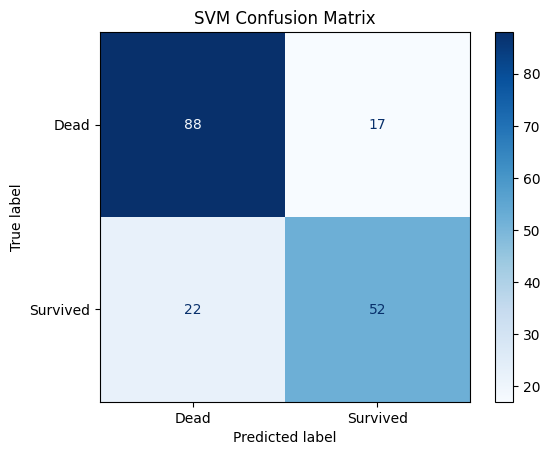


CV Accuracy: 0.7890 ± 0.0167
Each fold  : [0.8045 0.8034 0.7865 0.7584 0.7921]


In [7]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

best_svm = SVC(**grid.best_params_, random_state=42, probability=True)
best_svm.fit(X_train, y_train)
y_pred = best_svm.predict(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Dead', 'Survived']).plot(cmap='Blues')
plt.title(f'SVM Confusion Matrix')
plt.show()

scores = cross_val_score(best_svm, X_scaled, y_final, cv=5, scoring='accuracy')
print(f"\nCV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Each fold  : {scores.round(4)}")

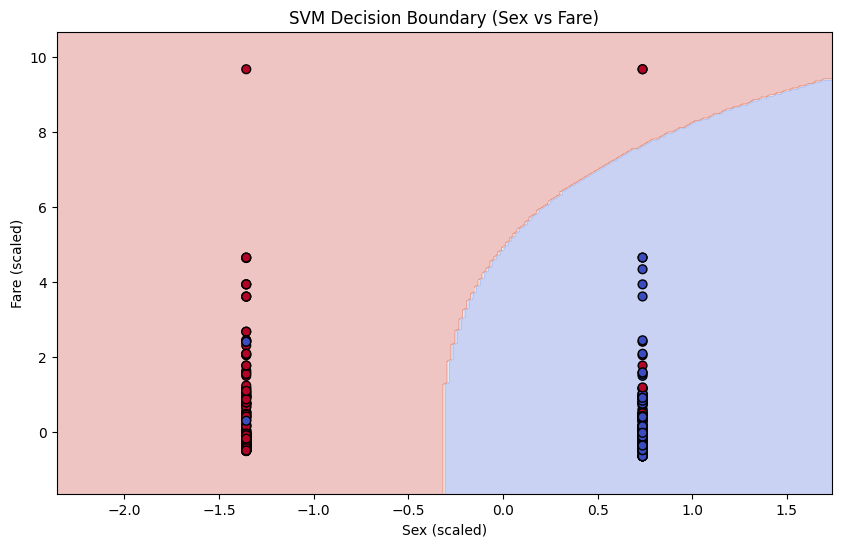

In [8]:
# can only plot 2D boundary — use Sex and Fare as they're strongest
import matplotlib.pyplot as plt
import numpy as np

x_plot = X_train[['Sex', 'Fare']].values
y_plot = y_train.values

svm_2d = SVC(kernel=grid.best_params_['kernel'],
             C=grid.best_params_['C'],
             gamma=grid.best_params_['gamma'])
svm_2d.fit(x_plot, y_plot)

# mesh grid
x_min, x_max = x_plot[:, 0].min() - 1, x_plot[:, 0].max() + 1
y_min, y_max = x_plot[:, 1].min() - 1, x_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(x_plot[:, 0], x_plot[:, 1], c=y_plot,
            cmap='coolwarm', edgecolors='k', s=40)
plt.xlabel('Sex (scaled)')
plt.ylabel('Fare (scaled)')
plt.title('SVM Decision Boundary (Sex vs Fare)')
plt.show()